# Targeted Attack + Low-Rank Vaccination by Score Tier

attack points that belong to structure (low noise score)
or noise (high noise score), then apply k-rank SVD vaccination and measure
restoration rate and post-vaccination ASR.


In [3]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import json
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# DATA_DIR = Path('spambase_50_50')
DATA_DIR = Path('/home/skada009/aro/spambase_10_40_50')
SCORES_DIR = Path('noise_scoring_outputs/20260324_203954')
OUTPUT_DIR = Path('targeted_vaccination_results_10_40_50')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ALPHA = 0.1
MAXITERS = 300
ATTACK_PCTS = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
K_RANKS = [1, 2, 3, 5, 10, 15, 20, 30, 40, 50, 57]

Device: cuda
GPU: NVIDIA RTX A6000


## 1. Load Data, Model, and Noise Scores

In [4]:
data = np.load(DATA_DIR / 'train_test_data.npz')
X_test = data['X_test'].astype(np.float32)
y_test = data['y_test']
n_test, n_features = X_test.shape

prep = np.load(DATA_DIR / 'preprocessing.npz')
weights = prep['weights']
bounds = [prep['bounds_min'], prep['bounds_max']]


class SpambaseNet(nn.Module):
    def __init__(self, D_in):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(D_in, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 2), nn.Softmax(dim=-1)
        )

    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
            return self.layer(x).squeeze(0)
        return self.layer(x)


checkpoint = torch.load(DATA_DIR / 'spambase_mlp.pth', map_location=device)
model = SpambaseNet(checkpoint['D_in']).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

X_test_t = torch.FloatTensor(X_test).to(device)
with torch.no_grad():
    test_preds = model(X_test_t).argmax(dim=1).cpu().numpy()
correct_mask = (test_preds == y_test)
correct_indices = np.where(correct_mask)[0]
n_correct = len(correct_indices)

print(f'Test set: {n_test} samples, {n_features} features')
print(f'Correctly classified: {n_correct}/{n_test} ({n_correct/n_test:.2%})')

Test set: 2301 samples, 57 features
Correctly classified: 2058/2301 (89.44%)


In [6]:
from turtle import home


score1_removal_order = np.load('/home/skada009/aro/experiments/noise_scoring_outputs/20260324_203954/test_clean_data_score1_removed_index.npy').astype(int)
score2_value = np.load('/home/skada009/aro/experiments/noise_scoring_outputs/20260324_203954/test_clean_data_score2_noise_scores.npy')

# Noisiest-first orderings, filtered to correctly-classified only
score1_order = [idx for idx in score1_removal_order if correct_mask[idx]]
score2_order = [idx for idx in np.argsort(score2_value)[::-1] if correct_mask[idx]]

score_orders = {'Score 1': score1_order, 'Score 2': score2_order}
print(f'Eligible points per score ordering: {len(score1_order)}')

Eligible points per score ordering: 2057


## 2. Attack All Correctly-Classified Points



In [7]:
from Adverse import zero_gradients


def clip(current, low_bound, up_bound, device):
    low_bound = torch.FloatTensor(low_bound).to(device)
    up_bound = torch.FloatTensor(up_bound).to(device)
    return torch.max(torch.min(current, up_bound), low_bound)


def deepfool(x_old, net, maxiters, alpha, bounds, weights=[], overshoot=0.002):
    """
    :param image: tabular sample
    :param net: network 
    :param maxiters: maximum number of iterations ran to generate the adversarial examples
    :param alpha: scaling factor used to control the growth of the perturbation
    :param bounds: bounds of the datasets with respect to each feature
    :param weights: feature importance vector associated with the dataset at hand
    :param overshoot: used as a termination criterion to prevent vanishing updates (default = 0.02).
    :return: minimal perturbation that fools the classifier, number of iterations that it required, new estimated_label and perturbed image
    """    
    input_shape = x_old.detach().cpu().numpy().shape
    x = x_old.detach().clone().requires_grad_(True)
    
    output = net.forward(x)
    orig_pred = output.max(0, keepdim=True)[1]  # get the index of the max log-probability
    origin = orig_pred.clone().detach()
    I = []
    if orig_pred.item() == 0:
        I = [0, 1]
    else:
        I = [1, 0]       
    w = np.zeros(input_shape)
    r_tot = np.zeros(input_shape)    
    k_i = origin.clone()
    loop_i = 0
    while torch.eq(k_i, origin) and loop_i < maxiters:                
        # Origin class
        output[I[0]].backward(retain_graph=True)
        grad_orig = x.grad.detach().cpu().numpy().copy()        
        # Target class
        zero_gradients(x)
        output[I[1]].backward(retain_graph=True)
        cur_grad = x.grad.detach().cpu().numpy().copy()            
        # set new w and new f
        w = cur_grad - grad_orig
        f = (output[I[1]] - output[I[0]]).detach().cpu().numpy()
        pert = abs(f)/np.linalg.norm(w.flatten())    
        # compute r_i and r_tot
        # Added 1e-4 for numerical stability
        r_i =  (pert+1e-4) * w / np.linalg.norm(w)          
        if len(weights) > 0:
            r_i /= np.array(weights)
        # limit huge step
        r_i = alpha * r_i / np.linalg.norm(r_i)            
        r_tot = np.float32(r_tot + r_i)       
        pert_x = x_old + (1 + overshoot) * torch.from_numpy(r_tot).to(x_old.device)
        if len(bounds) > 0:
            pert_x = clip(pert_x, bounds[0], bounds[1], x_old.device)               
        x = pert_x.detach().clone().requires_grad_(True)
        output = net.forward(x)      
        k_i = torch.tensor(np.argmax(output.detach().cpu().numpy().flatten()), device=origin.device)                   
        loop_i += 1
    r_tot = (1+overshoot)*r_tot    
    pert_x = clip(pert_x, bounds[0], bounds[1], x_old.device)
    return int(orig_pred.item()), int(k_i.item()), pert_x.detach().cpu().numpy(), loop_i

In [8]:
print(f'\n{"="*50}')
print(f'  Generating Adversarial Samples (DeepFool)')
print(f'{"="*50}')

X_adv = np.copy(X_test)
attack_success = np.zeros(n_test, dtype=int)
t0 = time.time()

for i, idx in enumerate(correct_indices):
    x = torch.FloatTensor(X_test[idx]).to(device)
    orig_pred, adv_pred, x_adv_np, _ = deepfool(x, model, MAXITERS, ALPHA, bounds, weights=[])
    
    X_adv[idx] = x_adv_np
    attack_success[idx] = 1 if orig_pred != adv_pred else 0

    if (i + 1) % 200 == 0 or i == 0:
        elapsed = time.time() - t0
        eta = elapsed / (i + 1) * (n_correct - i - 1)
        n_succ = attack_success[correct_indices[:i+1]].sum()
        print(f'  [{i+1:>4d}/{n_correct}] success so far: {n_succ}/{i+1} | ETA: {eta:.0f}s')

n_succ = attack_success[correct_indices].sum()
print(f'  Done: {n_succ}/{n_correct} ({n_succ/n_correct:.2%}) | {time.time()-t0:.1f}s')

np.savez_compressed(
    OUTPUT_DIR / 'adversarial_samples.npz',
    X_adv_deepfool=X_adv,
    success_deepfool=attack_success
)
print('\nAdversarial samples saved to', OUTPUT_DIR / 'adversarial_samples.npz')


  Generating Adversarial Samples (DeepFool)
  [   1/2058] success so far: 1/1 | ETA: 188s
  [ 200/2058] success so far: 200/200 | ETA: 6s
  [ 400/2058] success so far: 400/400 | ETA: 5s
  [ 600/2058] success so far: 600/600 | ETA: 4s
  [ 800/2058] success so far: 800/800 | ETA: 4s
  [1000/2058] success so far: 1000/1000 | ETA: 3s
  [1200/2058] success so far: 1200/1200 | ETA: 3s
  [1400/2058] success so far: 1400/1400 | ETA: 2s
  [1600/2058] success so far: 1600/1600 | ETA: 1s
  [1800/2058] success so far: 1800/1800 | ETA: 1s
  [2000/2058] success so far: 2000/2000 | ETA: 0s
  Done: 2058/2058 (100.00%) | 6.2s

Adversarial samples saved to targeted_vaccination_results_10_40_50/adversarial_samples.npz


In [9]:
print(f'\n{"="*50}')
print(f'  ASR Check Before Vaccination')
print(f'{"="*50}')
n_succ = attack_success[correct_indices].sum()
print(f'DeepFool: {n_succ}/{n_correct} ({n_succ/n_correct:.2%}) attacks succeeded')


  ASR Check Before Vaccination
DeepFool: 2058/2058 (100.00%) attacks succeeded


## 3. Vaccination Sweep



In [10]:
def vaccinate_and_classify(X_mixed, k, model, device):
    """Apply k-rank SVD approximation, clip to [0,1], classify with model."""
    U, S, Vt = np.linalg.svd(X_mixed, full_matrices=False)
    X_vacc = (U[:, :k] * S[:k]) @ Vt[:k, :]
    X_vacc = np.clip(X_vacc, 0, 1).astype(np.float32)
    with torch.no_grad():
        preds = model(torch.FloatTensor(X_vacc).to(device)).argmax(dim=1).cpu().numpy()
    return preds


rows = []
t_total = time.time()

for score_name, order in score_orders.items():
    n_eligible = len(order)
    for attack_pct in ATTACK_PCTS:
        n_attack = max(1, int(n_eligible * attack_pct / 100))

        # Noisy tier: first n_attack in noisiest-first order
        noisy_indices = order[:n_attack]
        # Structural tier: last n_attack in noisiest-first order (most structural)
        structural_indices = order[-n_attack:]

        for tier_name, tier_idx in [('structural', structural_indices), ('noisy', noisy_indices)]:
            # Construct mixed matrix: replace targeted tier with adversarial versions
            X_mixed = np.copy(X_test)
            n_successfully_attacked = 0
            for idx in tier_idx:
                if attack_success[idx]:
                    X_mixed[idx] = X_adv[idx]
                    n_successfully_attacked += 1

            if n_successfully_attacked == 0:
                for k in K_RANKS:
                    rows.append({
                        'score_type': score_name, 'tier': tier_name,
                        'attack_pct': attack_pct, 'k': k,
                        'n_targeted': len(tier_idx), 'n_attacked': 0,
                        'restoration_rate': 0.0, 'asr_after': 0.0,
                    })
                continue

            # Single SVD, then evaluate at each k
            U, S, Vt = np.linalg.svd(X_mixed, full_matrices=False)

            for k in K_RANKS:
                X_vacc = (U[:, :k] * S[:k]) @ Vt[:k, :]
                X_vacc = np.clip(X_vacc, 0, 1).astype(np.float32)
                with torch.no_grad():
                    preds = model(torch.FloatTensor(X_vacc).to(device)).argmax(dim=1).cpu().numpy()

                n_restored = sum(
                    1 for idx in tier_idx
                    if attack_success[idx] and preds[idx] == y_test[idx]
                )
                restoration_rate = n_restored / n_successfully_attacked

                rows.append({
                    'score_type': score_name, 'tier': tier_name,
                    'attack_pct': attack_pct, 'k': k,
                    'n_targeted': len(tier_idx), 'n_attacked': n_successfully_attacked,
                    'restoration_rate': restoration_rate, 'asr_after': 1 - restoration_rate,
                })

        print(f'{score_name} | attack_pct={attack_pct:>3d}% done ({time.time()-t_total:.1f}s)')

df = pd.DataFrame(rows)
df.to_csv(OUTPUT_DIR / 'vaccination_sweep.csv', index=False)
print(f'\nSweep complete: {len(df)} rows, saved to {OUTPUT_DIR / "vaccination_sweep.csv"}')

Score 1 | attack_pct= 10% done (0.3s)
Score 1 | attack_pct= 20% done (0.3s)
Score 1 | attack_pct= 30% done (0.3s)
Score 1 | attack_pct= 40% done (0.4s)
Score 1 | attack_pct= 50% done (0.4s)
Score 1 | attack_pct= 60% done (0.5s)
Score 1 | attack_pct= 70% done (0.5s)
Score 1 | attack_pct= 80% done (0.6s)
Score 1 | attack_pct= 90% done (0.6s)
Score 1 | attack_pct=100% done (0.7s)
Score 2 | attack_pct= 10% done (0.7s)
Score 2 | attack_pct= 20% done (0.8s)
Score 2 | attack_pct= 30% done (0.8s)
Score 2 | attack_pct= 40% done (0.8s)
Score 2 | attack_pct= 50% done (0.9s)
Score 2 | attack_pct= 60% done (0.9s)
Score 2 | attack_pct= 70% done (1.0s)
Score 2 | attack_pct= 80% done (1.0s)
Score 2 | attack_pct= 90% done (1.1s)
Score 2 | attack_pct=100% done (1.1s)

Sweep complete: 440 rows, saved to targeted_vaccination_results_10_40_50/vaccination_sweep.csv


## 4. Heatmaps

Saved vaccination_score1_structural.png


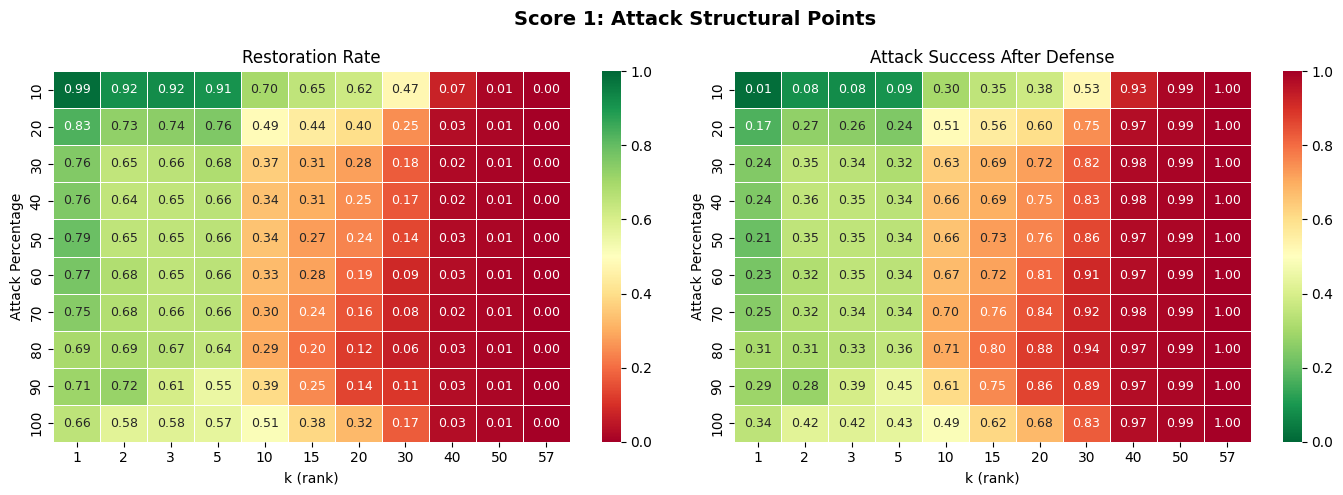

Saved vaccination_score1_noisy.png


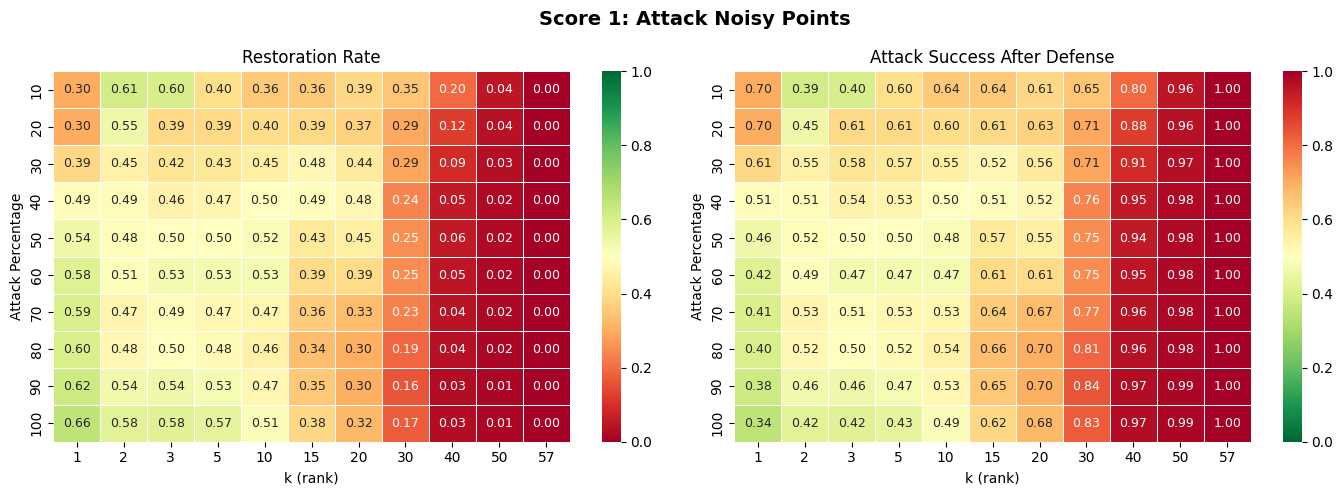

Saved vaccination_score2_structural.png


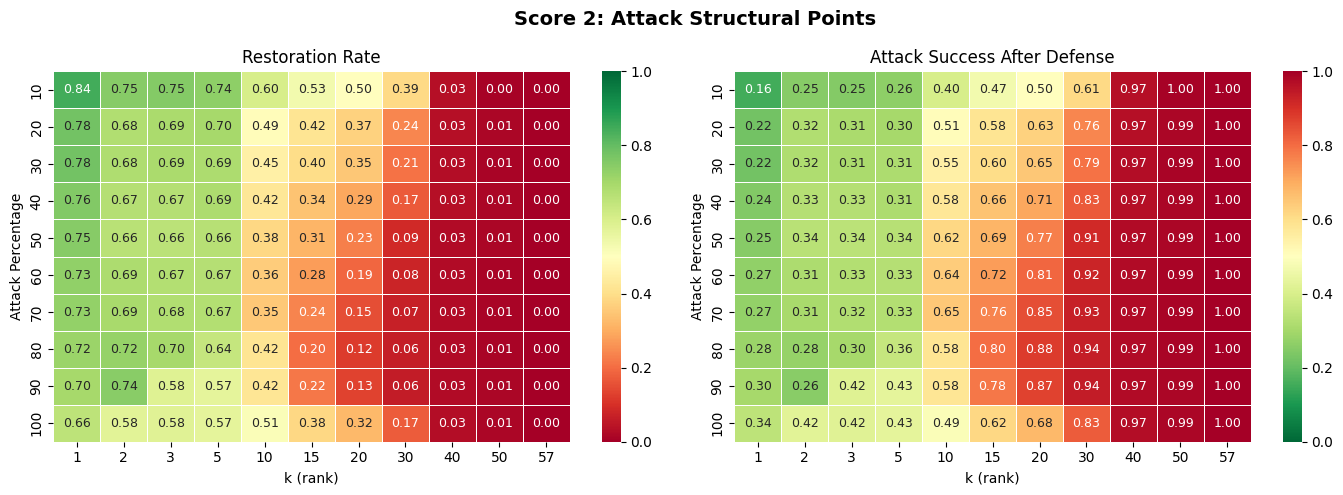

Saved vaccination_score2_noisy.png


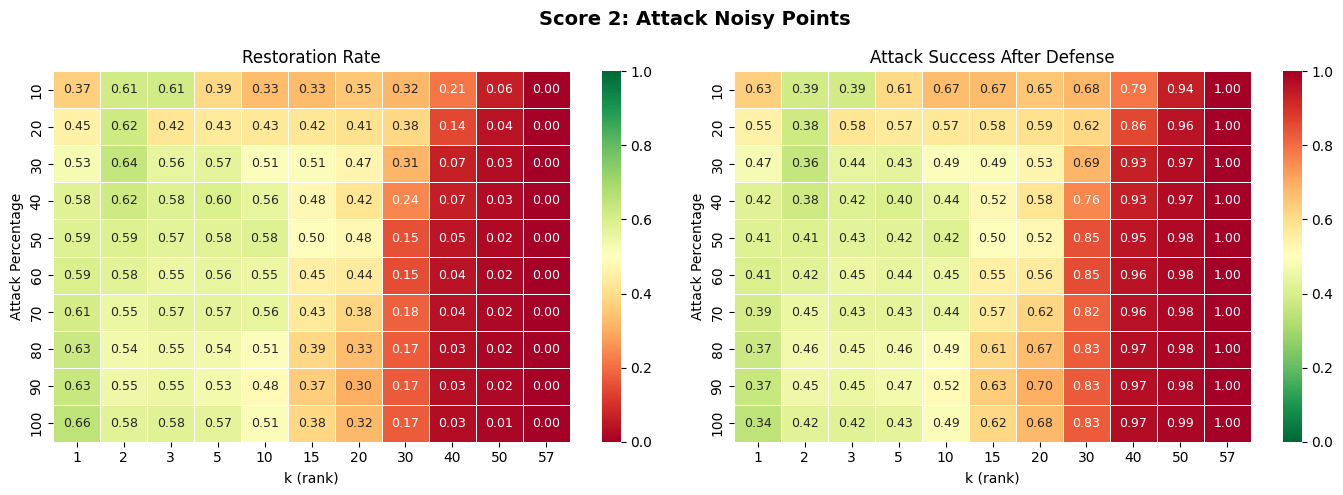

In [11]:
def plot_vaccination_heatmaps(df, score_name, tier_name, output_dir):
    """Produce heatmaps for restoration rate and ASR after defense."""
    sub = df[(df['score_type'] == score_name) & (df['tier'] == tier_name)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{score_name}: Attack {tier_name.capitalize()} Points', fontsize=14, fontweight='bold')

    # Restoration rate heatmap
    pivot_restoration = sub.pivot(index='attack_pct', columns='k', values='restoration_rate')
    pivot_restoration = pivot_restoration.sort_index(ascending=True)
    sns.heatmap(
        pivot_restoration, ax=axes[0], annot=True, fmt='.2f', cmap='RdYlGn',
        vmin=0, vmax=1, linewidths=0.5, annot_kws={'size': 9}
    )
    axes[0].set_title('Restoration Rate')
    axes[0].set_xlabel('k (rank)')
    axes[0].set_ylabel('Attack Percentage')

    # Attack success after defense heatmap
    pivot_asr = sub.pivot(index='attack_pct', columns='k', values='asr_after')
    pivot_asr = pivot_asr.sort_index(ascending=True)
    sns.heatmap(
        pivot_asr, ax=axes[1], annot=True, fmt='.2f', cmap='RdYlGn_r',
        vmin=0, vmax=1, linewidths=0.5, annot_kws={'size': 9}
    )
    axes[1].set_title('Attack Success After Defense')
    axes[1].set_xlabel('k (rank)')
    axes[1].set_ylabel('Attack Percentage')

    plt.tight_layout()
    fname = f'vaccination_{score_name.lower().replace(" ", "")}_{tier_name}.png'
    fig.savefig(output_dir / fname, dpi=150, bbox_inches='tight')
    print(f'Saved {fname}')
    plt.show()


for score_name in score_orders:
    for tier_name in ['structural', 'noisy']:
        plot_vaccination_heatmaps(df, score_name, tier_name, OUTPUT_DIR)

## 5. Save Summary

In [9]:
summary = {
    'config': {
        'alpha': ALPHA, 'maxiters': MAXITERS,
        'attack_method': 'DeepFool',
        'attack_pcts': ATTACK_PCTS, 'k_ranks': K_RANKS,
        'n_test': int(n_test), 'n_correct': int(n_correct),
    },
    'attack_success': {
        'deepfool': int(attack_success[correct_indices].sum())
    },
}
with open(OUTPUT_DIR / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('All results saved to', OUTPUT_DIR)
for p in sorted(OUTPUT_DIR.iterdir()):
    print(f'  {p.name:45s} ({p.stat().st_size/1024:.1f} KB)')

All results saved to targeted_vaccination_results_10_40_50
  adversarial_samples.npz                       (261.8 KB)
  summary.json                                  (0.4 KB)
  vaccination_score1_noisy.png                  (211.1 KB)
  vaccination_score1_structural.png             (223.7 KB)
  vaccination_score2_noisy.png                  (215.6 KB)
  vaccination_score2_structural.png             (222.8 KB)
  vaccination_sweep.csv                         (28.9 KB)
